In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet('train.parquet')
df

,model,generation
0,gpt2,"In July 2014, US President Barack Obama visite..."
1,llama-chat,"A young girl, Bernadette, lived in a village o..."
2,human,Former England footballer Paul Gascoigne will ...
3,chatgpt,I've been thinking lot about Apple's future la...
4,llama-chat,"I​n​ ​w​h​i​s​p​e​r​s​,​ ​I​ ​c​o​n​f​e​s​s​ ​..."
...,...,...
796795,gpt4,AMERICAN tennis player Robby Ginepri dashed th...
796796,cohere,"Ingredients \n1 pound medium shrimp, peeled a..."
796797,cohere-chat,Sure! Here's the body of a plot summary for a ...
796798,cohere,London taxi drivers have collected more than...


In [3]:
df.head()

,model,generation
0,gpt2,"In July 2014, US President Barack Obama visite..."
1,llama-chat,"A young girl, Bernadette, lived in a village o..."
2,human,Former England footballer Paul Gascoigne will ...
3,chatgpt,I've been thinking lot about Apple's future la...
4,llama-chat,"I​n​ ​w​h​i​s​p​e​r​s​,​ ​I​ ​c​o​n​f​e​s​s​ ​..."


In [4]:
df.shape   # rows, columns

(796800, 2)

In [5]:
df.columns

Index(['model', 'generation'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 796800 entries, 0 to 796799
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   model       796800 non-null  object
 1   generation  796800 non-null  object
dtypes: object(2)
memory usage: 12.2+ MB


In [7]:
df.describe(include='all')

,model,generation
count,796800,796800
unique,12,775609
top,mpt,​
freq,66495,44


In [8]:
# Target Variable (LABEL) Analysis

In [9]:
df['model'].unique()

array(['gpt2', 'llama-chat', 'human', 'chatgpt', 'mistral', 'gpt4',
       'mpt-chat', 'mistral-chat', 'gpt3', 'mpt', 'cohere-chat', 'cohere'],
      dtype=object)

In [10]:
df['model'].value_counts()

model
mpt             66495
gpt3            66486
gpt2            66458
mistral-chat    66454
mistral         66439
chatgpt         66427
cohere          66409
human           66387
mpt-chat        66343
llama-chat      66323
cohere-chat     66290
gpt4            66289
Name: count, dtype: int64

In [11]:
df['model'].value_counts(normalize=True)

model
mpt             0.083453
gpt3            0.083441
gpt2            0.083406
mistral-chat    0.083401
mistral         0.083382
chatgpt         0.083367
cohere          0.083345
human           0.083317
mpt-chat        0.083262
llama-chat      0.083237
cohere-chat     0.083195
gpt4            0.083194
Name: proportion, dtype: float64

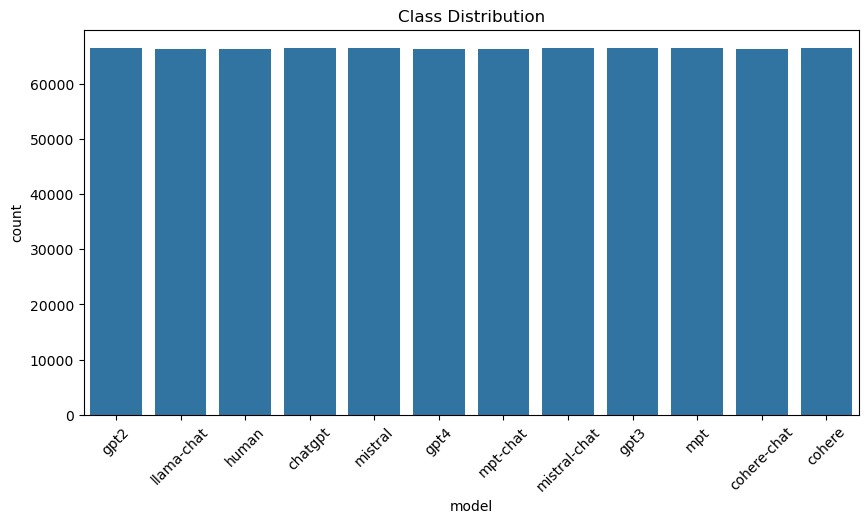

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x='model', data=df)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [13]:
# Text (Feature) Analysis

In [14]:
df['generation'].iloc[0]

'In July 2014, US President Barack Obama visited Turkey, meeting then Prime Minister Recep Tayyip Erdogan and other political figures to discuss increasing trade. But Obama is not a fan of online video games when it\'s tied to terrorism – because, as an advisor noted to BIRN this month, they may be leading young people to violent extremism.\n\n\nThere is still a lot untapped potential for social good in the virtual world. In the recent global survey called Gaming at a Glance 2015, by Nielsen Online Gaming Forum, around half of gamers were found happy. Of the two percent who didn\'t seem so pleased, nine percent said it was due to \'inherent negativity\' generated by the game.\n\n\nAnd these gamers – we call them fans - are often extremely loyal to their favourite content creators. In some cases, as many as 90% consider them personal friends. And yet, they have an outsize influence on today\'s digital platforms. We see examples of how social interaction and gaming can bring people toget

In [15]:
df.sample(5)

,model,generation
438988,cohere-chat,I​t​ ​w​a​s​ ​a​ ​d​a​r​k​ ​a​n​d​ ​s​t​o​r​m​...
203220,gpt2,A crime family is group of people who have com...
35599,mistral-chat,"This is a beautiful, well-made movie, based on..."
172734,cohere-chat,Ich möchte gerade an einen neuen Binocular Ste...
124718,llama-chat,Hey fellow gamers!\n\nI've been thinking about...


In [16]:
# Text Length Analysis

In [17]:
df['text_length'] = df['generation'].apply(len)

In [18]:
df['text_length'].describe()

count    796800.000000
mean       1517.247666
std        1005.943031
min           1.000000
25%         879.000000
50%        1383.000000
75%        1979.000000
max      140088.000000
Name: text_length, dtype: float64

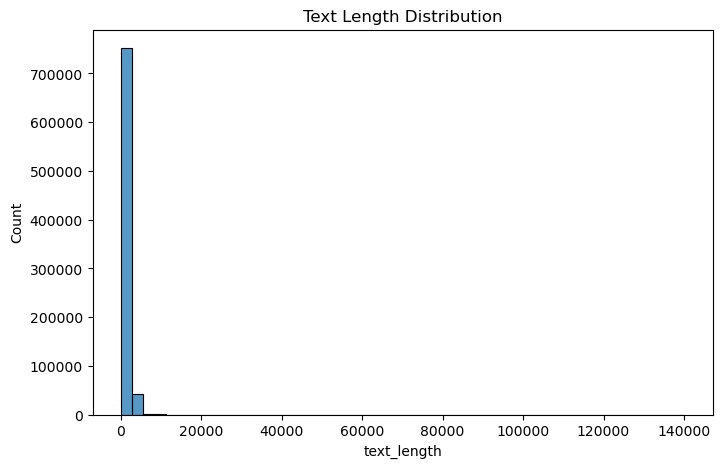

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [20]:
# Words Count

In [21]:
df['word_count'] = df['generation'].apply(lambda x: len(x.split()))

In [22]:
df['word_count'].describe()

count    796800.000000
mean        234.887048
std         137.380641
min           1.000000
25%         141.000000
50%         224.000000
75%         319.000000
max       13261.000000
Name: word_count, dtype: float64

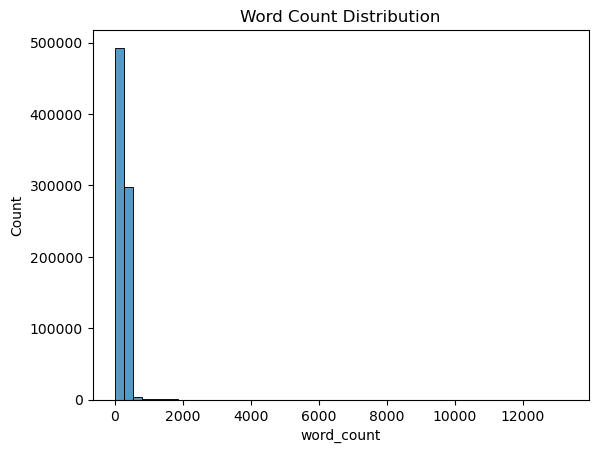

In [23]:
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

In [24]:
# Check Missing Values
df.isnull().sum()

model          0
generation     0
text_length    0
word_count     0
dtype: int64

In [25]:
# Duplicate Data

df.duplicated().sum()

21175

In [26]:
# Class-wise Text Analysis

In [27]:
df.groupby('model')['word_count'].mean()

model
chatgpt         260.294444
cohere          229.980951
cohere-chat     184.688807
gpt2            291.368323
gpt3            133.524110
gpt4            270.874715
human           290.792218
llama-chat      265.563515
mistral         253.316275
mistral-chat    199.749511
mpt             275.689285
mpt-chat        162.795713
Name: word_count, dtype: float64

In [28]:
df.groupby('model')['text_length'].mean()

model
chatgpt         1751.245849
cohere          1453.485642
cohere-chat     1174.284719
gpt2            1776.535165
gpt3             835.820910
gpt4            1803.327158
human           1843.209183
llama-chat      1739.934578
mistral         1577.926564
mistral-chat    1302.926656
mpt             1821.223836
mpt-chat        1127.222375
Name: text_length, dtype: float64

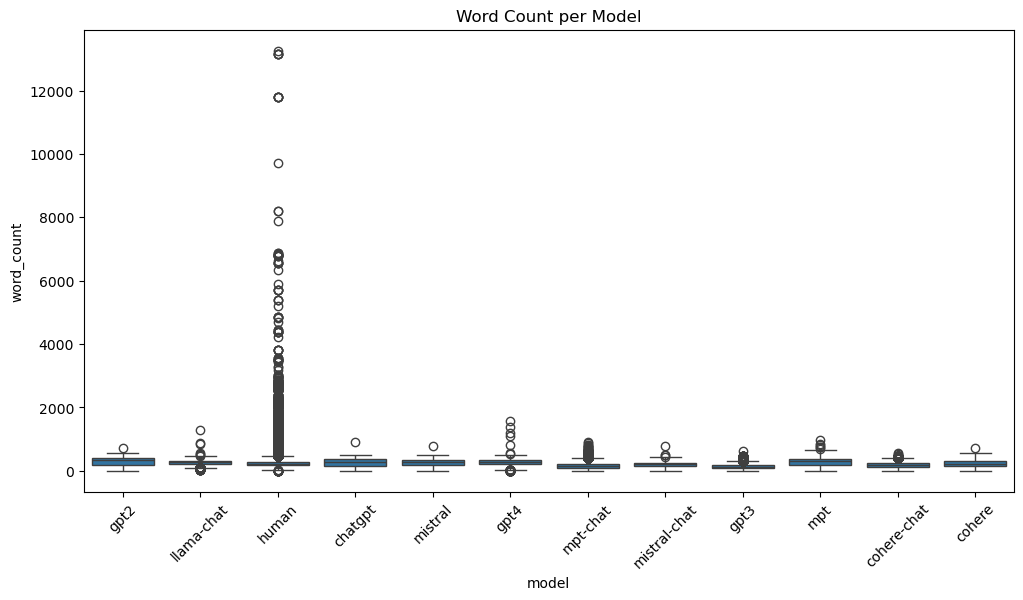

In [29]:
plt.figure(figsize=(12,6))
sns.boxplot(x='model', y='word_count', data=df)
plt.xticks(rotation=45)
plt.title("Word Count per Model")
plt.show()

In [30]:
# Most Common Words (Basic NLP)

from collections import Counter

all_words = " ".join(df['generation']).split()
Counter(all_words).most_common(20)

[('the', 7458557),
 ('and', 4721985),
 ('of', 4101477),
 ('a', 3823257),
 ('to', 3755392),
 ('in', 2542775),
 ('is', 2006643),
 ('The', 1445602),
 ('that', 1385615),
 ('for', 1382918),
 ('with', 1162351),
 ('I', 962179),
 ('on', 949179),
 ('as', 825734),
 ('was', 791453),
 ('thе', 779709),
 ('\u200bt\u200bh\u200be\u200b', 778264),
 ('it', 716333),
 ('his', 662349),
 ('by', 644446)]

In [31]:
# Stopwords Removal

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_words = [word for word in all_words if word.lower() not in stop_words]
Counter(filtered_words).most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arjun\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('thе', 779709),
 ('\u200bt\u200bh\u200be\u200b', 778264),
 ('-', 493769),
 ('\u200ba\u200bn\u200bd\u200b', 476669),
 ('аnd', 476431),
 ('\u200bo\u200bf\u200b', 409831),
 ('оf', 408608),
 ('\u200ba\u200b', 408093),
 ('\u200b', 403584),
 ('а', 403458),
 ('\u200bt\u200bo\u200b', 383325),
 ('tо', 382687),
 ('1', 375567),
 ('cup', 364309),
 ('also', 358270),
 ('1/2', 265089),
 ('\u200bi\u200bn\u200b', 258084),
 ('іn', 256632),
 ('one', 245137),
 ('\u200bi\u200bs\u200b', 205060)]

In [32]:
# pip install wordcloud

In [31]:
print(df.shape)

(796800, 4)


In [32]:
# Duplicate Data

df = df.drop_duplicates()
print(df.shape)

(775625, 4)


In [33]:
# Duplicate Data

df.duplicated().sum()

0

In [34]:
# Skewed Distribution
# 👉 Most texts are short
# 👉 Few texts are very long (outliers)

df = df[df['word_count'] < 1000]

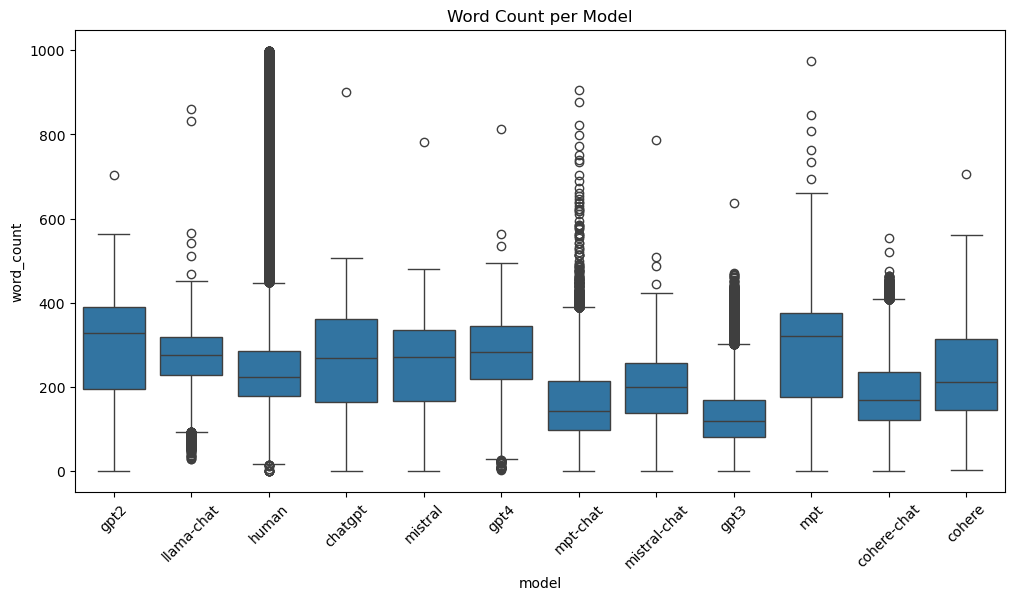

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(x='model', y='word_count', data=df)
plt.xticks(rotation=45)
plt.title("Word Count per Model")
plt.show()

In [36]:
# Compare Models by Text Style

In [37]:
df.groupby('model')[['word_count']].agg(['mean', 'std', 'min', 'max'])

# 👉 Helps detect:

# Which model writes longer?
# Which is consistent?

word_count                     
                    mean         std min  max
model                                        
chatgpt       261.789954  108.666779   1  902
cohere        231.016217  104.146568   3  705
cohere-chat   185.973286   86.082795   1  554
gpt2          291.762955  115.068921   1  704
gpt3          135.119262   75.045361   1  637
gpt4          272.069684   91.118430   3  814
human         266.157923  148.270174   1  999
llama-chat    266.021724   64.725075  28  860
mistral       253.483962   96.708145   1  783
mistral-chat  200.315369   75.072158   1  786
mpt           277.320388  119.952538   1  975
mpt-chat      163.786443   87.310471   1  905

In [38]:
# Vocabulary Richness

df['unique_words'] = df['generation'].apply(lambda x: len(set(x.split())))
df['vocab_richness'] = df['unique_words'] / df['word_count']

df.groupby('model')['vocab_richness'].mean()

# 👉 Insight:

# Human text → more variation
# AI text → repetitive patterns

model
chatgpt         0.626073
cohere          0.625225
cohere-chat     0.637871
gpt2            0.537984
gpt3            0.650782
gpt4            0.630104
human           0.641843
llama-chat      0.627954
mistral         0.618179
mistral-chat    0.673683
mpt             0.682614
mpt-chat        0.771843
Name: vocab_richness, dtype: float64

In [39]:
# Punctuation Analysis

df['num_exclam'] = df['generation'].apply(lambda x: x.count('!'))
df['num_questions'] = df['generation'].apply(lambda x: x.count('?'))

df.groupby('model')[['num_exclam','num_questions']].mean()


,num_exclam,num_questions
model,,
chatgpt,0.170555,0.167975
cohere,0.234460,0.462716
cohere-chat,0.137943,0.328313
gpt2,0.348704,0.477520
gpt3,0.061100,0.106104
gpt4,0.180015,0.292557
human,0.339745,0.391322
llama-chat,0.292325,0.429650
mistral,0.435888,0.444446


In [40]:
# Sentence Count

df['sentence_count'] = df['generation'].apply(lambda x: len(x.split('.')))
df.groupby('model')['sentence_count'].mean()


model
chatgpt         15.652525
cohere          12.997555
cohere-chat     11.120337
gpt2            15.800268
gpt3             9.379443
gpt4            16.496336
human           14.734753
llama-chat      13.877540
mistral         13.656419
mistral-chat    11.205533
mpt             14.320558
mpt-chat         8.253684
Name: sentence_count, dtype: float64

In [41]:
# Stopword Ratio

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['stopword_ratio'] = df['generation'].apply(
    lambda x: sum(1 for w in x.split() if w.lower() in stop_words) / len(x.split())
)

df.groupby('model')['stopword_ratio'].mean()

model
chatgpt         0.339090
cohere          0.349601
cohere-chat     0.354597
gpt2            0.368681
gpt3            0.352965
gpt4            0.336664
human           0.341715
llama-chat      0.348788
mistral         0.342491
mistral-chat    0.345667
mpt             0.309022
mpt-chat        0.315457
Name: stopword_ratio, dtype: float64

In [42]:
# Most Common Words per Model

from collections import Counter

for model in df['model'].unique():
    text = " ".join(df[df['model']==model]['generation'])
    print(f"\n{model}")
    print(Counter(text.split()).most_common(10))



gpt2
[('the', 705167), ('a', 459555), ('of', 444532), ('to', 389321), ('and', 323769), ('is', 297144), ('in', 255023), ('The', 193124), ('that', 189187), ('I', 173872)]

llama-chat
[('the', 702255), ('and', 554267), ('of', 411394), ('to', 391299), ('a', 381019), ('in', 224440), ('that', 152317), ('for', 145561), ('is', 136151), ('The', 121813)]

human
[('the', 697501), ('and', 406732), ('to', 346933), ('of', 343598), ('a', 297227), ('in', 240335), ('is', 154096), ('for', 116882), ('with', 111726), ('that', 107645)]

chatgpt
[('the', 789421), ('and', 580126), ('of', 415183), ('a', 367332), ('to', 359328), ('in', 233701), ('for', 144175), ('is', 138573), ('The', 127205), ('with', 113573)]

mistral
[('the', 529228), ('of', 317925), ('a', 315966), ('to', 311621), ('and', 298046), ('in', 205979), ('is', 201809), ('>', 134856), ('that', 130736), ('The', 129804)]

gpt4
[('the', 842647), ('and', 484667), ('of', 479841), ('a', 389482), ('to', 335891), ('in', 271364), ('is', 164749), ('The', 14

In [43]:
# N-gram Analysis

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['generation'])

print(vectorizer.get_feature_names_out())


['and the' 'as the' 'at the' 'by the' 'for the' 'from the' 'has been'
 'he was' 'in the' 'is the' 'it is' 'of the' 'on the' 'such as' 'that the'
 'the world' 'to be' 'to the' 'with the' 'оf thе']


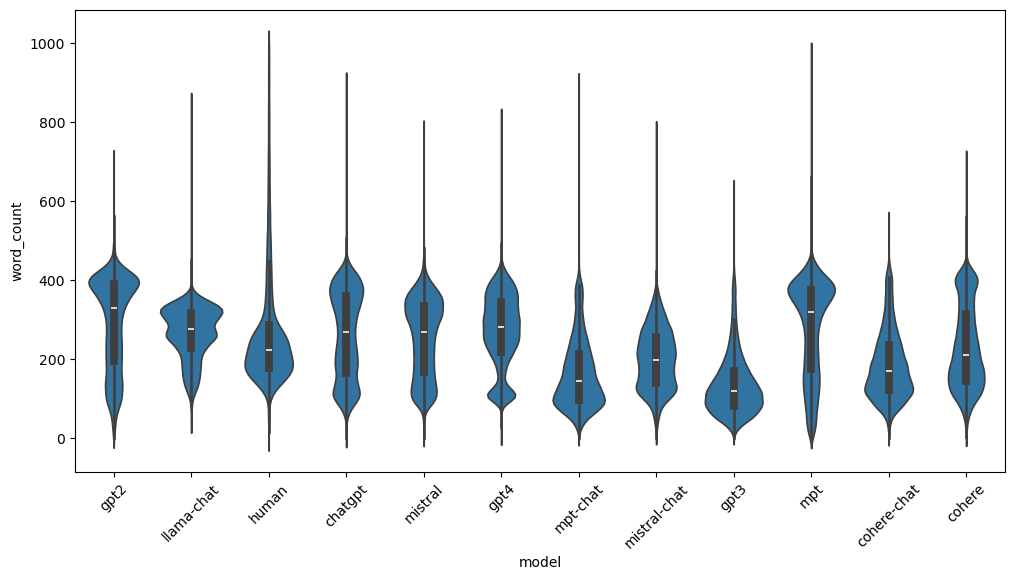

In [43]:
# Length vs Model Visualization

plt.figure(figsize=(12,6))
sns.violinplot(x='model', y='word_count', data=df)
plt.xticks(rotation=45)
plt.show()


In [45]:

# Dataset is balanced → no class imbalance problem
# Different models have different:
    # Text length
    # Vocabulary richness
    # Writing style
# There are duplicates → must remove
# Text distribution is skewed → handle outliers
# Common words are mostly stopwords → need preprocessing

In [46]:
# Remove Duplicates

# Check duplicates
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Verify
print("Duplicates after:", df.duplicated().sum())
print("New shape:", df.shape)


Duplicates before: 0
Duplicates after: 0
New shape: (774505, 10)


In [47]:
# Handle Outliers

# From your EDA:

# Max word count ≈ 13,000+
# Most texts ≈ 100–400 words


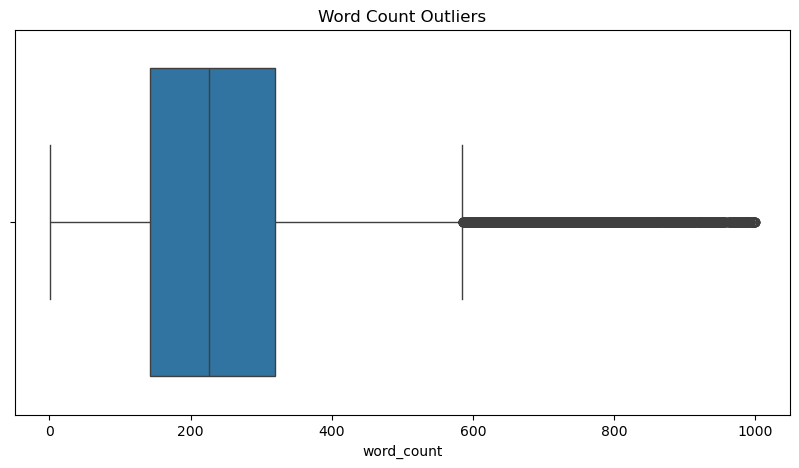

In [48]:
# Visualize Outliers

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['word_count'])
plt.title("Word Count Outliers")
plt.show()

In [49]:
# Remove Extreme Outliers

# Keep only reasonable text lengths : Simple, fast
df = df[df['word_count'] < 1000]

print("Shape after removing outliers:", df.shape)


Shape after removing outliers: (774505, 10)


In [50]:
# Using IQR (Interquartile Range) : More statistical (advanced projects)

Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['word_count'] >= lower_bound) & (df['word_count'] <= upper_bound)]

print("Shape after IQR filtering:", df.shape)

Shape after IQR filtering: (771242, 10)


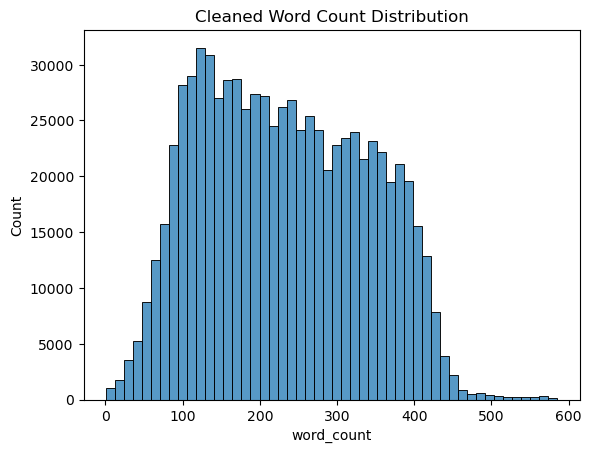

In [51]:
# Re-check Distribution

sns.histplot(df['word_count'], bins=50)
plt.title("Cleaned Word Count Distribution")
plt.show()


In [52]:
# Reset Index

df = df.reset_index(drop=True)

In [53]:
# Sanity Check

print(df.shape)
print(df['model'].value_counts())


(771242, 10)
model
llama-chat      65456
mistral-chat    65351
mistral         65314
gpt2            64991
mpt-chat        64845
mpt             64770
chatgpt         64723
gpt4            64677
cohere          64624
cohere-chat     64012
gpt3            63305
human           59174
Name: count, dtype: int64
